# PTB-XL ECG Dataset Exploration

## Objective

The goal of this notebook is to explore the PTB-XL ECG dataset and understand its structure before developing machine learning models.

This notebook focuses on learning:

- What the PTB-XL dataset is
- Why it is widely used in biomedical AI research
- What information each ECG recording contains
- How ECG data differ from tabular clinical datasets


# Part1: ECG Dataset Exploration

## What is PTB-XL?

PTB-XL is a large public electrocardiogram (ECG) dataset developed by PhysioNet.

It contains over 21,000 clinical 12-lead ECG recordings collected from nearly 19,000 patients.

Each ECG recording lasts approximately 10 seconds and is labeled by cardiologists with diagnostic information.

Because of its large size and high-quality annotations, PTB-XL has become one of the most widely used datasets for developing and evaluating AI models for ECG analysis.

## What is PhysioNet
PhysioNet is a free online database that provides medical datasets and software for researchers.

Think of it as GitHub for medical data, especially physiological signals such as:

ECG (electrocardiograms)
EEG (brain signals)
Blood pressure
Heart rate
Respiratory signals
ICU patient data

Researchers all over the world use PhysioNet to develop and evaluate medical AI algorithms.

## Why is PTB-XL Important?

Compared with smaller ECG datasets, PTB-XL provides:

- A large number of ECG recordings
- Multiple diagnostic labels
- Standardized clinical annotations
- High-quality expert labeling

These characteristics make PTB-XL an excellent dataset for developing machine learning and deep learning models for ECG classification.

In [1]:
# Install the ECG library
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 70.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [2]:
# Import libraries (wfdb reads ECG records, plt draws the ECG waveform. )
import wfdb
import matplotlib.pyplot as plt

In [3]:
# Load ECG record 00001_lr from the 100 Hz PTB-XL folder on PhysioNet
#read a WFDB record
record = wfdb.rdrecord(
    #name of ECG record _lr = low resolution 100Hz
    "00001_lr",
    #the record is online on PhysioNet, not on my computer
    pn_dir="ptb-xl/1.0.3/records100/00000"
)

In [4]:
# Check the sampling rate
#record.fs = how many times per second the ECG was recorded.
print("Sampling rate", record.fs)

Sampling rate 100


The ECG machine recorded 100 samples every second.

In [5]:
# ECG shape, p_signal=physical signal, .shape=its dimensions
print("Signal shape:", record.p_signal.shape)

Signal shape: (1000, 12)


1000 time points(rows)recorded over the 10s ECG, 12 ECG leads

In [6]:
#Lead names
print("Signal shape:", record.sig_name)
# select Lead II: lead_number = 1

Signal shape: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [7]:
# Check the first few ECG values
print(record.p_signal[:5])

[[-0.119 -0.055  0.064  0.086 -0.091  0.004 -0.069 -0.031  0.    -0.026
  -0.039 -0.079]
 [-0.116 -0.051  0.065  0.083 -0.09   0.006 -0.064 -0.036 -0.003 -0.031
  -0.034 -0.074]
 [-0.12  -0.044  0.076  0.082 -0.098  0.016 -0.058 -0.034 -0.01  -0.028
  -0.029 -0.069]
 [-0.117 -0.038  0.08   0.077 -0.098  0.021 -0.05  -0.03  -0.015 -0.023
  -0.022 -0.064]
 [-0.103 -0.031  0.072  0.066 -0.087  0.021 -0.045 -0.027 -0.02  -0.019
  -0.018 -0.058]]


## ECG Waveform

In [8]:
# choose one ECG lead
lead_number=1

In [9]:
# Get the ECG signal
ecg_signal = record.p_signal[:, lead_number]
#record.p_signal=whole ECG dataset
#[:, lead_number]= Take every time point from Lead II

In [10]:
# Create figure (width=12inches,Height=4inches)
plt.figure(figsize=(12,4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

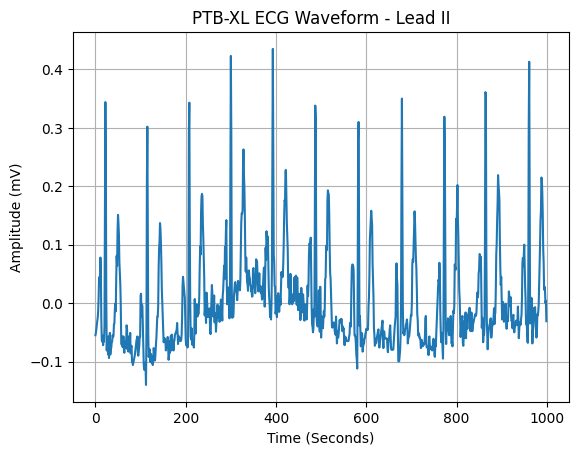

In [18]:
# Draw the ECG
plt.plot(ecg_signal)
# Add title
plt.title("PTB-XL ECG Waveform - Lead II")

# Add axis labels
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude (mV)")

# Add grid
plt.grid()

# Show the figure
plt.show()

## ECG Waveform Components

A normal ECG waveform consists of three major components:

- **P wave:** Represents atrial depolarization (the atria contract).
- **QRS complex:** Represents ventricular depolarization (the ventricles contract). It is usually the tallest part of the ECG.
- **T wave:** Represents ventricular repolarization (the ventricles recover before the next heartbeat).

These waveform components are important because AI models learn to recognize changes in their shape, duration, and amplitude to identify different heart conditions.


## How AI Could Analyze ECG Signals

An ECG is a time-series signal that records the electrical activity of the heart over time.

Machine learning and deep learning models can be trained to recognize patterns in the P wave, QRS complex, T wave, rhythm, and relationships among the 12 leads.

These patterns may help classify cardiac conditions such as arrhythmias, myocardial infarction, and conduction abnormalities.

In this notebook, I only performed ECG exploration and basic signal processing. No AI classification model was trained.

In [13]:
!pip install scipy

In [14]:
# Check the signal range
print("Maximum value:", ecg_signal.max())
print("Minimum value:", ecg_signal.min())

Maximum value: 0.435
Minimum value: -0.14


In [15]:
#Find the R peaks
from scipy.signal import find_peaks

# Find R peaks in Lead II
peaks, _ = find_peaks(
    ecg_signal,
    height=0.2,    #Only detect peaks greater than 0.2mV
    distance=50)   #Detected peaks must be at least 50 sampling points apart

print("Number of R peaks:", len(peaks))


Number of R peaks: 11


### R-Peak Detection Parameters

The `height=0.2` parameter removes small peaks that are unlikely to be R waves.

The `distance=50` parameter requires detected peaks to be at least 50 samples apart. Since the sampling rate is 100 Hz, this corresponds to 0.5 seconds.

These values were selected manually for this ECG recording. They may not work equally well for other patients, leads, or noisy ECG signals.

## Heart rate

In [16]:
#Impory the library
import numpy as np

# Get the sampling rate from the ECG record
sampling_rate = record.fs
#Total recording time (10s)
duration = len(ecg_signal) / sampling_rate

# Method 1: Estimate heart rate by counting R peaks
heart_rate = len(peaks) * 60 / duration

# Method 2: Estimate heart rate using the median R-R interval
# Calculate R-R intervals (seconds)
rr_intervals = np.diff(peaks) / sampling_rate
# Median R-R interval
median_rr = np.median(rr_intervals)
# Estimate heart rate
heart_rate_rr = 60 / median_rr

print(f"Recording duration: {duration:.1f} seconds")
print(f"Number of detected R peaks: {len(peaks)}")
print(f"Heart rate (Peak Count): {heart_rate:.1f} bpm")
print(f"Median R-R interval: {median_rr:.3f} seconds")
print(f"Heart rate (Median R-R): {heart_rate_rr:.1f} bpm")

Recording duration: 10.0 seconds
Number of detected R peaks: 11
Heart rate (Peak Count): 66.0 bpm
Median R-R interval: 0.935 seconds
Heart rate (Median R-R): 64.2 bpm


## Label R peak

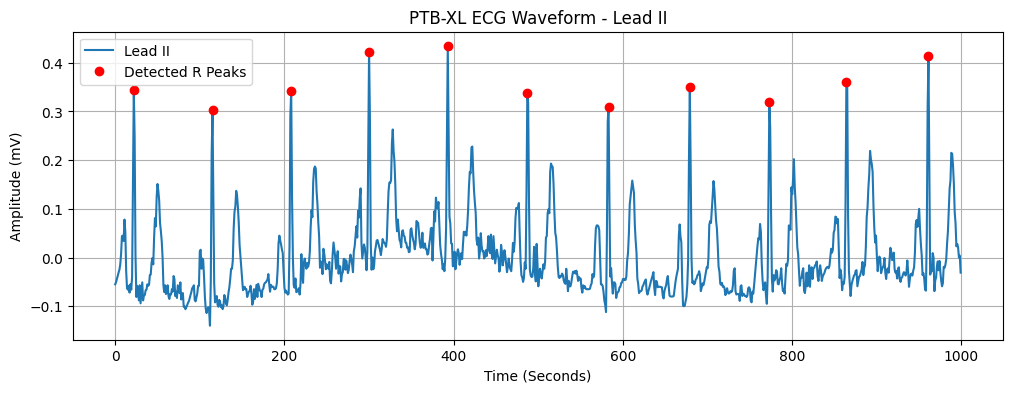

In [17]:
plt.figure(figsize=(12,4))

plt.plot(ecg_signal, label="Lead II")
plt.plot(peaks, ecg_signal[peaks], "ro", label="Detected R Peaks")

plt.title("PTB-XL ECG Waveform - Lead II")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.legend()
# create a figure folder
import os

os.makedirs("figures", exist_ok=True)

plt.savefig("figures/leadII_rpeaks.png", dpi=300, bbox_inches="tight")

plt.show()

## Observation

The ECG waveform from Lead II shows regular cardiac cycles with clearly visible R peaks.

Peak Courts: A total of **11 R peaks** were detected over the 10-second ECG recording, corresponding to an estimated heart rate of approximately **66 beats per minute (bpm)**.
R-R Interval: The estimated heart rate about **64.2 beats per minute (bpm)**. R-R Interval is more reliable method. Because if one R peak is missed or an extra false peak is detected, the heart rate estimate changes immediately.

This demonstrates that Python can automatically identify major ECG features and perform basic physiological analysis.

## Reflection

Through this exercise, I learned how to load a real ECG recording from the PTB-XL dataset, visualize the waveform, and detect R peaks using Python.

This helped me understand how ECG signals are represented as time-series data and provided a foundation for future AI-based ECG analysis.

# Part 2: Understanding the 12 ECG Leads

A standard ECG records the heart's electrical activity from 12 different views.

Although all leads record the same heartbeat, each lead looks different because it observes the electrical signal from a different direction.

In [ ]:
# Show the names of all 12 ECG leads
print(record.sig_name)

['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


## Types of ECG Leads

The 12 ECG leads can be divided into three groups:

### Limb Leads
- I
- II
- III

### Augmented Limb Leads
- aVR
- aVL
- aVF

### Chest Leads
- V1
- V2
- V3
- V4
- V5
- V6

Each lead provides a different view of the heart's electrical activity.

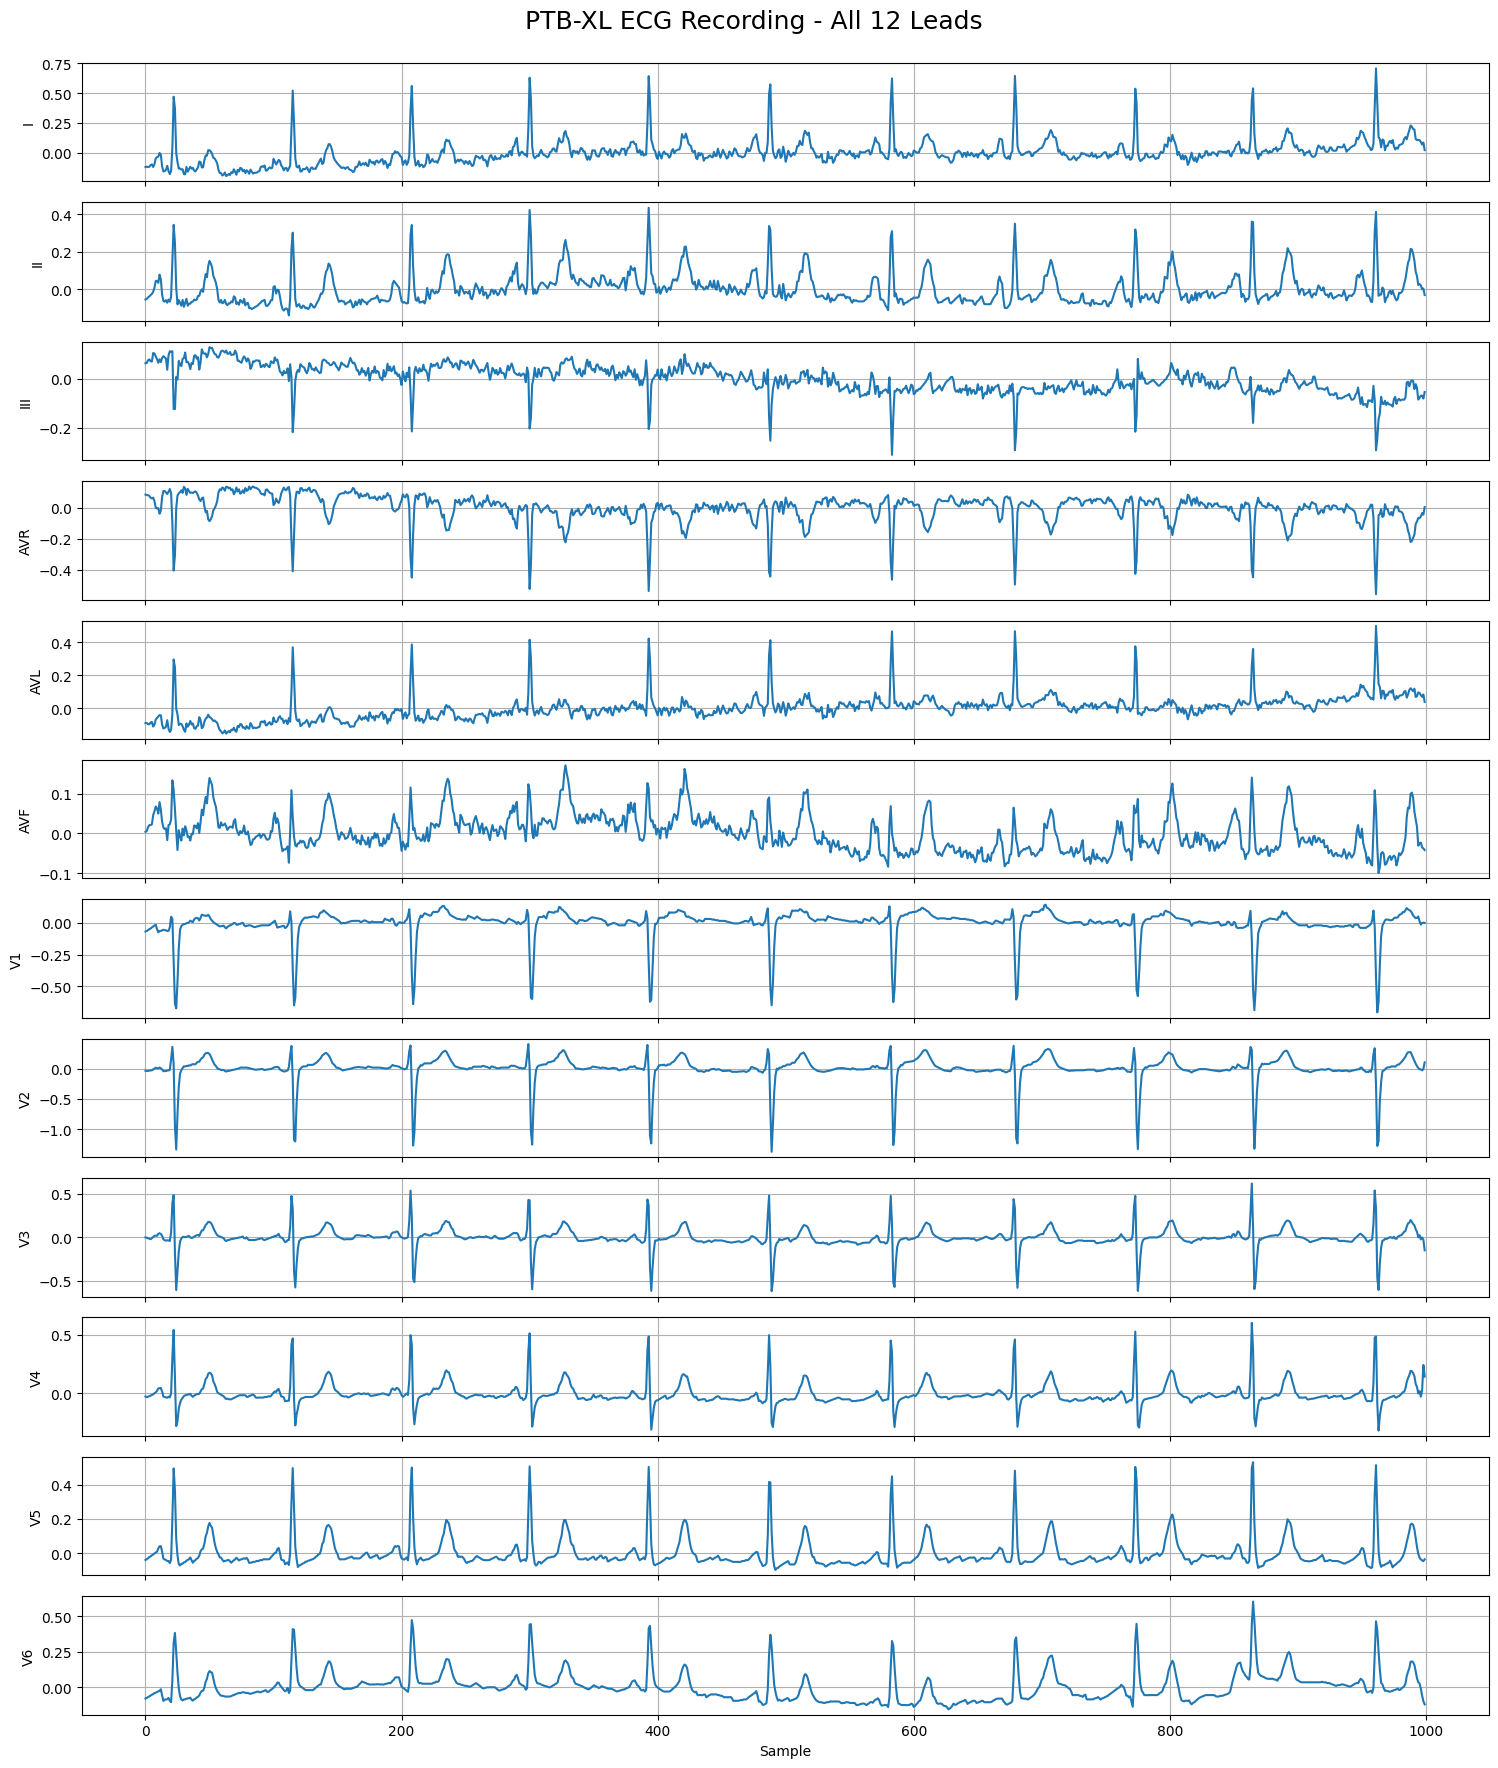

In [ ]:
# Create 12 graphs, one for each ECG lead
fig, axes = plt.subplots(
    12,
    1,
    figsize=(15, 18),
    sharex=True
)
#plt.subplots(): many samll graphs at the same time
#fig: whole page, axes: individual graphs
#12,1: 12rows, 1 column
#sharex=True: every graph has the same axis

# Plot each lead
for i in range(12): #repeat the next few lines 12 times
    axes[i].plot(record.p_signal[:, i])#axes[]: which graph [every row,lead]
    axes[i].set_ylabel(record.sig_name[i])
    axes[i].grid(True)

# Add labels and title
# Only the bottom graph gets the x-axis label. axes[-1]: the last graph
axes[-1].set_xlabel("Time (Seconds)")
fig.suptitle("PTB-XL ECG Recording - All 12 Leads", fontsize=18)
#Automatically adjust the spacing so the graphs don't overlap
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Save the figure
plt.savefig(
    "figures/all_12_leads.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

The waveforms look different across the 12 leads even though they come from the same ECG recording.

This happens because each lead observes the heart's electrical activity from a different direction. Some leads show larger upward waves, while others show smaller or inverted waves.

Using all 12 leads gives doctors and AI models a more complete view of the heart.

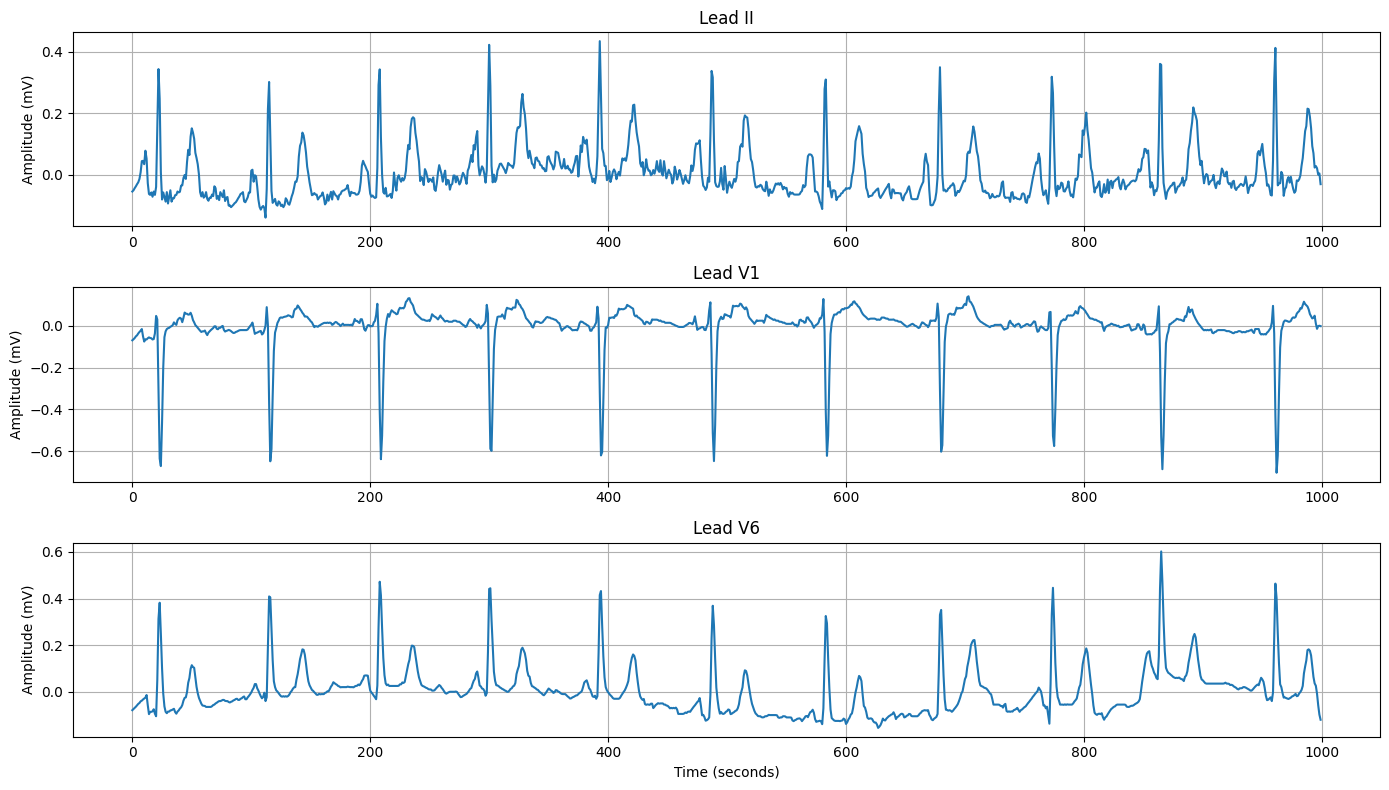

In [22]:
# Compare three leads
plt.figure(figsize=(14,8))

plt.subplot(3,1,1) #(rows,columns,position)
plt.plot(record.p_signal[:,1])
plt.title("Lead II")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.subplot(3,1,2)
plt.plot(record.p_signal[:,6])
plt.title("Lead V1")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.subplot(3,1,3)
plt.plot(record.p_signal[:,11])
plt.title("Lead V6")
plt.ylabel("Amplitude (mV)")
plt.grid()


plt.xlabel("Time (seconds)")
plt.tight_layout()

plt.savefig(
    "figures/compare_leadII_V1_V6.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Comparing Different ECG Leads

Lead II, V1, and V6 all record the same heartbeat, but the waveforms have different shapes and amplitudes.

This occurs because each lead measures the heart's electrical activity from a different angle.

These different perspectives provide complementary information, allowing doctors and AI models to detect abnormalities that may only appear in certain leads.

## Purpose: to use all 12 leads
Although all 12 leads record the same heartbeat, each lead observes the heart's electrical activity from a different direction.

Some heart abnormalities may only appear in certain leads. By analyzing all 12 leads together, AI models can learn more complete patterns and improve diagnostic accuracy compared with using a single lead.

## Difference from My Previous Heart Disease Project

My previous project used tabular clinical features, such as age, cholesterol level, and blood pressure, to train machine learning models for heart disease classification.

This ECG project uses raw time-series waveforms rather than tabular patient data. However, no machine learning or deep learning model was trained in this notebook.

The current project focuses on loading ECG records, understanding the 12-lead structure, visualizing waveforms, detecting R peaks, and estimating heart rate. These steps provide a foundation for a future ECG classification project.

# Limitations

This project has several limitations.

- Only one PTB-XL ECG recording was explored.
- The R peaks were detected using a manually selected threshold.
- The threshold may not work equally well for other patients or ECG leads.
- Only basic visualization and signal analysis were performed.
- The P wave, QRS boundaries, and T wave were not automatically detected.
- This project focuses on ECG signal exploration and basic signal processing. No AI model was trained or evaluated during this project.
- The project is intended for education and should not be used for clinical diagnosis.


## Reflection

Through this project, I learned how to load a real PTB-XL ECG record from PhysioNet, examine its sampling rate and dimensions, and visualize both single-lead and 12-lead ECG signals.

I also learned how to detect R peaks and estimate heart rate using two methods: peak counting and the median R-R interval. Comparing the two methods helped me understand that physiological measurements depend on both the signal quality and the accuracy of peak detection.

This project is an ECG signal exploration project rather than an AI classification project. It provides a useful foundation for future work involving ECG preprocessing, feature extraction, and machine learning classification.